In [1]:
import numpy as np
import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

In [2]:
df_ev = pd.read_csv("data/cleaned_chargingdata.csv")

In [5]:
# Remove timezone offset information from the string column before conversion
df_ev['connectionTime'] = df_ev['connectionTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev['disconnectTime'] = df_ev['disconnectTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev['doneChargingTime'] = df_ev['doneChargingTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)

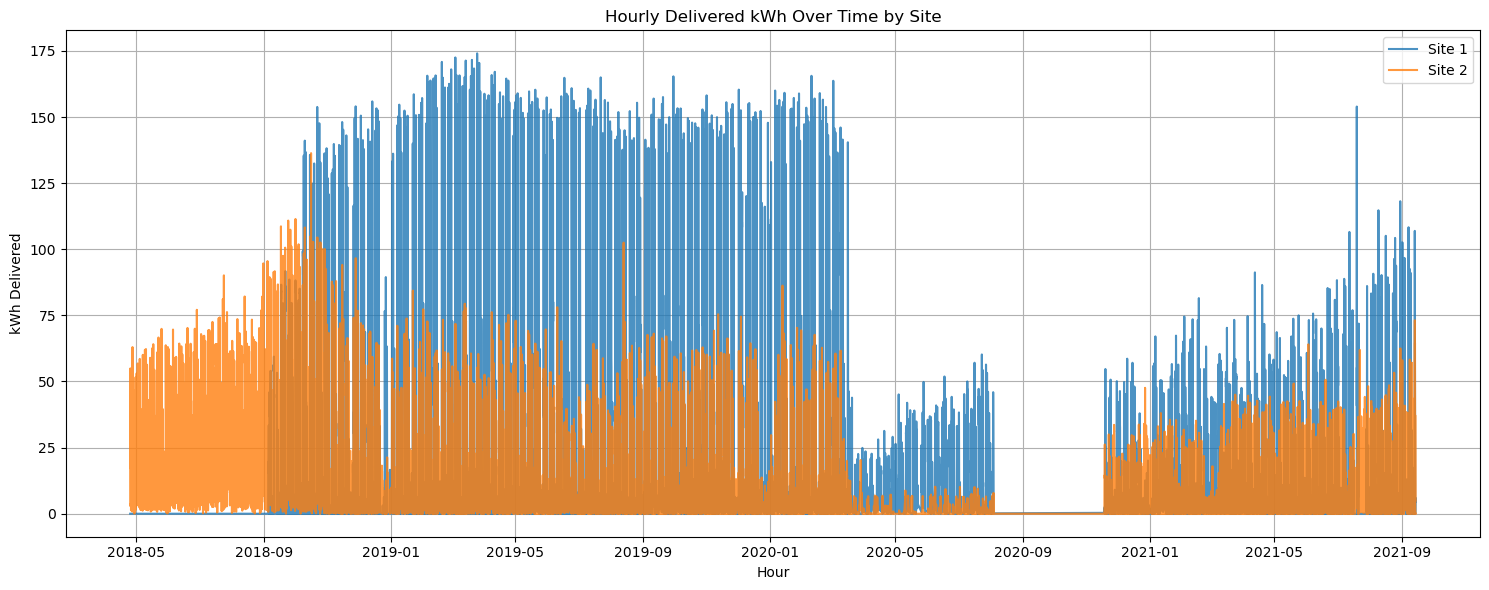

In [19]:
# Ensure 'connectionTime' and 'doneChargingTime' are in datetime format
df_ev['connectionTime'] = pd.to_datetime(df_ev['connectionTime'])
df_ev['doneChargingTime'] = pd.to_datetime(df_ev['doneChargingTime'])

# Create an empty DataFrame to store hourly kWh delivered
hourly_kwh = []

# Process each row/session
for _, row in df_ev.iterrows():
    # Extract session details
    start_time = row['connectionTime']
    end_time = row['doneChargingTime']
    total_kwh = row['kWhDelivered']
    site_id = row['siteID']
    
    # Compute the total charging duration in hours
    total_duration = (end_time - start_time).total_seconds() / 3600  # Convert to hours
    
    # Generate hourly timestamps between start and end
    current_time = start_time
    while current_time < end_time:
        # Calculate the end of the current hour
        hour_end = min(current_time.replace(minute=0, second=0, microsecond=0) + pd.Timedelta(hours=1), end_time)
        duration_in_hour = (hour_end - current_time).total_seconds() / 3600  # Duration in hours for this interval
        
        # Calculate kWh for this hour proportionally
        kwh_for_hour = total_kwh * (duration_in_hour / total_duration)
        
        # Append to the hourly kWh list
        hourly_kwh.append({
            'hour': current_time.replace(minute=0, second=0, microsecond=0),  # Round down to the hour
            'siteID': site_id,
            'kWhDelivered': kwh_for_hour
        })
        
        # Move to the next hour
        current_time = hour_end

# Create a DataFrame from the list of hourly data
hourly_kwh_df = pd.DataFrame(hourly_kwh)

# Group by hour and siteID and sum up the kWh delivered
hourly_kwh_summary = hourly_kwh_df.groupby(['hour', 'siteID'])['kWhDelivered'].sum().unstack(fill_value=0).reset_index()

# Rename columns for clarity
hourly_kwh_summary.columns.name = None  # Remove the multi-index name
hourly_kwh_summary.columns = ['hour', 'site_1_kWh', 'site_2_kWh']

# Plot the hourly delivered kWh for each site
plt.figure(figsize=(15, 6))
plt.plot(hourly_kwh_summary['hour'], hourly_kwh_summary['site_1_kWh'], label='Site 1', alpha=0.8)
plt.plot(hourly_kwh_summary['hour'], hourly_kwh_summary['site_2_kWh'], label='Site 2', alpha=0.8)
plt.title('Hourly Delivered kWh Over Time by Site')
plt.xlabel('Hour')
plt.ylabel('kWh Delivered')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [10]:
hourly_kwh_summary

,hour,site_1_kWh,site_2_kWh
0,2018-04-25 04:00:00,0.000000,3.602725
1,2018-04-25 05:00:00,0.000000,3.602725
2,2018-04-25 06:00:00,0.000000,8.867644
3,2018-04-25 07:00:00,0.000000,23.695252
4,2018-04-25 08:00:00,0.000000,50.152593
...,...,...,...
20993,2021-09-14 03:00:00,5.963001,0.000000
20994,2021-09-14 04:00:00,5.963001,0.000000
20995,2021-09-14 05:00:00,5.963001,0.000000
20996,2021-09-14 06:00:00,5.963001,0.000000


In [20]:
# Specify the date to check
specific_date = '2019-05-05'

# Filter df_ev for the specific date and site 1
filtered_sessions = df_ev[
    (df_ev['connectionTime'].dt.date == pd.to_datetime(specific_date).date()) &
    (df_ev['siteID'] == 1)
]

filtered_sessions

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,chargingDuration
62134,62179,5817,5ce4981bf9af8b26784ed8e0,2019-05-05 12:04:14,2019-05-05 16:55:19,2019-05-05 12:34:21,2.316,1_1_178_817_2019-05-05 19:04:14.094198,1,AG-1F09,1-1-178-817,America/Los_Angeles,1169.0,30.116667
62135,62180,5818,5ce4981bf9af8b26784ed8e1,2019-05-05 14:56:44,2019-05-05 15:49:00,2019-05-05 15:48:55,5.512,1_1_178_823_2019-05-05 21:56:43.553463,1,AG-1F08,1-1-178-823,America/Los_Angeles,1039.0,52.183333
62136,62181,5819,5ce4981bf9af8b26784ed8e2,2019-05-05 16:44:54,2019-05-05 20:54:09,2019-05-05 18:57:48,11.447,1_1_193_816_2019-05-05 23:44:54.012681,1,AG-1F05,1-1-193-816,America/Los_Angeles,413.0,132.900000


In [21]:
# Filter hourly_kwh_summary for the specific date and site 1
filtered_hourly_kwh = hourly_kwh_summary[
    (hourly_kwh_summary['hour'].dt.date == pd.to_datetime(specific_date).date())
]

print("Aggregated hourly kWh for site 1 on", specific_date)
print(filtered_hourly_kwh[['hour', 'site_1_kWh']])

Aggregated hourly kWh for site 1 on 2019-05-05
                    hour  site_1_kWh
8350 2019-05-05 00:00:00    0.000000
8351 2019-05-05 01:00:00    0.000000
8352 2019-05-05 02:00:00    0.000000
8353 2019-05-05 03:00:00    0.000000
8354 2019-05-05 04:00:00    0.000000
8355 2019-05-05 05:00:00    0.000000
8356 2019-05-05 06:00:00    0.000000
8357 2019-05-05 07:00:00    0.000000
8358 2019-05-05 08:00:00    0.000000
8359 2019-05-05 09:00:00    0.000000
8360 2019-05-05 10:00:00    0.000000
8361 2019-05-05 11:00:00    0.000000
8362 2019-05-05 12:00:00    2.316000
8363 2019-05-05 13:00:00    0.000000
8364 2019-05-05 14:00:00    0.345050
8365 2019-05-05 15:00:00    5.166950
8366 2019-05-05 16:00:00    1.300600
8367 2019-05-05 17:00:00    5.167946
8368 2019-05-05 18:00:00    4.978454
8369 2019-05-05 19:00:00    0.000000
8370 2019-05-05 20:00:00    0.000000
8371 2019-05-05 21:00:00    0.000000
8372 2019-05-05 22:00:00    0.000000


In [22]:
filtered_sessions['kWhDelivered'].sum()


19.275

In [23]:
filtered_hourly_kwh['site_1_kWh'].sum()

19.275